# 03 — ERP and Time-Frequency Analysis

**Goal.** Characterize the neural response to imagined left-fist (T1) vs
right-fist (T2) movements at the single-subject level, building the
sensory-to-cortical story that motivates the feature extraction and
classification choices in notebooks 04–05.

**Conceptual roadmap.**
1. **Time-domain ERPs.** Average voltage time-locked to cue onset. We
   expect modest cue-evoked sensory components (the auditory/visual cue
   triggers an ERP regardless of imagery content) but only weak
   differences between T1 and T2 in this domain — motor imagery is
   primarily an *oscillatory* phenomenon, not an evoked-potential one.
2. **Time-frequency analysis.** Morlet wavelets to compute power in the
   mu (8–13 Hz) and beta (13–30 Hz) bands as a function of time. This is
   where motor imagery's signature lives: **event-related desynchronization
   (ERD)** — a *decrease* in mu/beta power on sensorimotor cortex
   contralateral to the imagined movement, reflecting cortical activation
   (idling rhythm interrupted).
3. **Contralateral vs ipsilateral comparison.** The textbook prediction:
   left fist imagery (T1) → stronger ERD on C4 (right motor cortex);
   right fist imagery (T2) → stronger ERD on C3 (left motor cortex).
   If we see this, classification is plausible. If we don't, we need to
   understand why before building a classifier.
4. **Statistical inference.** Cluster permutation tests to identify
   where T1 and T2 reliably differ — sets up which features are worth
   extracting downstream.

**Caveat.** Single subject, ~45 trials per condition. Statistical power
is limited. Treat findings here as exploratory; the multi-subject
analysis in notebook 06 is where claims firm up.

## Load Processed Epochs

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mne
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

# Local modules
from features import ( # type: ignore
    compute_evoked,
    compute_evoked_contrast,
    compute_tfr_morlet,
    apply_tfr_baseline,
    get_motor_channels,
)
from visualization import ( # type: ignore
    plot_erp_butterfly,
    plot_erp_comparison,
    plot_erp_topomap_series,
    plot_tfr_single_channel,
    plot_tfr_topomap_band,
    plot_tfr_lateralization,
)
from stats import cluster_test_evoked, cluster_test_tfr # type: ignore

# Reproducibility — TFR is deterministic but cluster permutations aren't
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

mne.set_log_level('WARNING')  # quiet MNE's per-call chatter; we'll
# print what we want explicitly

In [2]:
EPOCHS_PATH = '../data/processed/sub-001_epo.fif'
epochs = mne.read_epochs(EPOCHS_PATH, preload=True)

print(f"Loaded {len(epochs)} epochs")
print(f"Conditions: {epochs.event_id}")
print(f"Channels: {len(epochs.ch_names)} EEG")
print(f"Sampling rate: {epochs.info['sfreq']} Hz")
print(f"Time window: {epochs.tmin}s to {epochs.tmax}s "
      f"({len(epochs.times)} samples)")
print(f"\nTrials per condition:")
for cond in epochs.event_id:
    print(f"  {cond}: {len(epochs[cond])}")

Loaded 45 epochs
Conditions: {'T1': 2, 'T2': 3}
Channels: 64 EEG
Sampling rate: 160.0 Hz
Time window: -0.5s to 4.0s (721 samples)

Trials per condition:
  T1: 23
  T2: 22


Before any analysis, confirm:
- Trial counts per condition are roughly balanced. If T1 ≠ T2 by more
  than a few trials, AutoReject was systematically dropping one
  condition more, which we'd want to investigate.
- The time window matches what notebook 02 wrote (−0.5 to 4.0 s).
- The sampling rate matches (160 Hz).

These look correct → proceed.

## ERPs - Time-domain ERPs 

The expectation: with ~45 trials per condition, the signal-to-noise ratio
for any ERP component will be modest. We're not expecting clean N100s and
P300s here — the cue is the same across T1 and T2 (an arrow indicating
which hand), so common sensory components will be similar. We're looking
for any **lateralized** time-domain difference, which in motor preparation
is usually a slow contralateral negativity (the "lateralized readiness
potential" or LRP analog) developing over hundreds of milliseconds.

In [3]:
evoked_t1 = compute_evoked(epochs, condition='T1')  # left fist
evoked_t2 = compute_evoked(epochs, condition='T2')  # right fist
evoked_diff = compute_evoked_contrast(epochs, 'T1', 'T2')

print(f"T1 (left fist):  averaged over {evoked_t1.nave} trials")
print(f"T2 (right fist): averaged over {evoked_t2.nave} trials")

T1 (left fist):  averaged over 23 trials
T2 (right fist): averaged over 22 trials


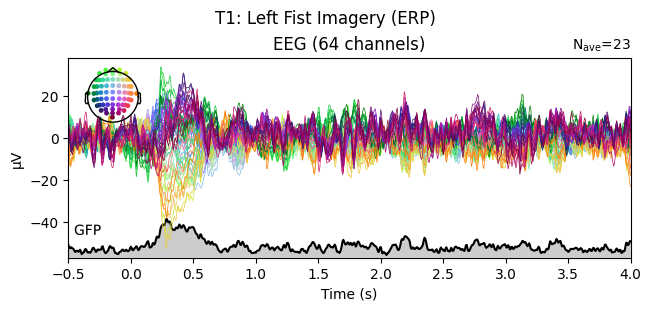

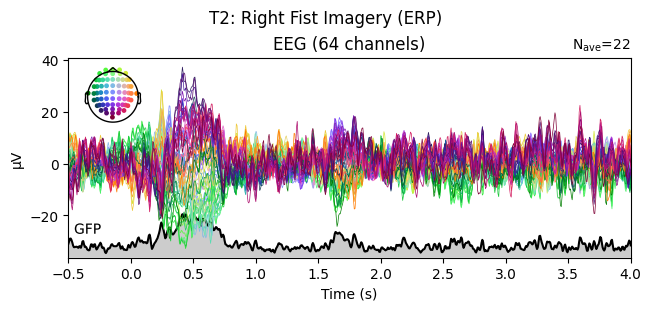

In [4]:
fig_t1 = plot_erp_butterfly(evoked_t1, title='T1: Left Fist Imagery (ERP)')
fig_t2 = plot_erp_butterfly(evoked_t2, title='T2: Right Fist Imagery (ERP)')
plt.show()

The time-domain ERPs show a clear cue-evoked sensory response in the first 500 ms — identical across conditions, as expected since the cue is identical. After that, the GFP returns to baseline and there is no obvious sustained time-domain difference between T1 and T2. This is exactly the predicted finding: motor imagery's signal lives in the frequency domain, not in time-locked voltage averages. The next section confirms this by showing mu/beta ERD where the ERP analysis finds nothing.

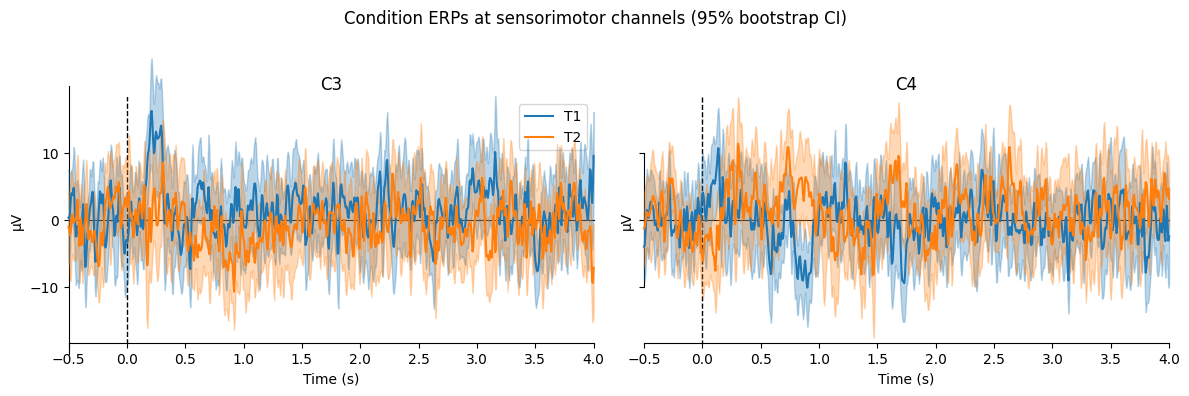

In [14]:
fig_compare = plot_erp_comparison(
    epochs,
    picks=['C3', 'C4'],
    conditions=['T1', 'T2'],
    title='Condition ERPs at sensorimotor channels (95% bootstrap CI)',
)

Adding 95% bootstrap confidence intervals around the condition means makes explicit what the unshaded comparison hinted at: the trial-to-trial variability at any given timepoint is comparable in magnitude to the condition mean itself, so the apparent T1-vs-T2 separation visible in places is well within noise. The bands overlap continuously throughout the sustained imagery window on both C3 and C4. The only window with near-separation is 200–400 ms on C3, where the cue-evoked response is larger for T1 — possibly a chance asymmetry, possibly an attentional difference, but not a movement-related lateralization (the direction is wrong for that). Cluster permutation testing in Part 3 will determine whether any of these apparent differences survive multiple-comparison correction; visual inspection alone suggests no.

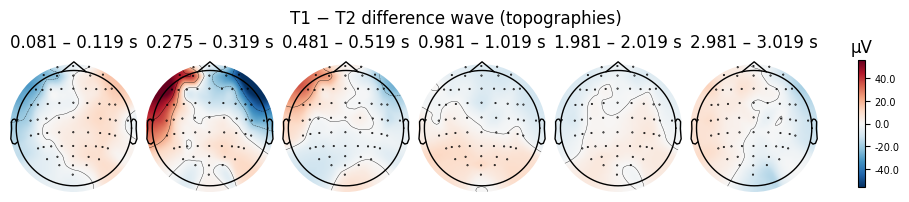

In [15]:
fig_topo = plot_erp_topomap_series(
    evoked_diff,
    times=[0.1, 0.3, 0.5, 1.0, 2.0, 3.0],
    title='T1 − T2 difference wave (topographies)',
)
plt.show()

# Interpreting the difference-wave topographies.

The difference wave (T1 − T2) cancels signal that is identical across conditions but preserves signal that differs for any reason — including stimulus-driven cue differences, not just movement-related lateralization. The expected motor-imagery signature is a central lateralization (opposite polarity over left vs right sensorimotor strip) in the 1–3 s sustained imagery window.
What we see instead: a strong frontal lateralization at 275–319 ms (the cue response, which differs between conditions because the leftward vs rightward arrow stimuli themselves are spatially mirrored), and near-blank topographies in the 1–3 s imagery windows. At 1 s there is at most a faint hint of central lateralization in the predicted direction; by 2 s and 3 s the topographies are essentially flat.
With ~22 trials per condition, this is the predicted outcome: motor imagery's time-domain signature is too small to survive single-subject averaging at this trial count. The frequency-domain analysis in Part 2 will reveal what the time domain is hiding.

## Time-Frequency Analysis (where the signal lives)

Motor imagery's neural signature is **event-related desynchronization
(ERD)**: a *decrease* in oscillatory power in the mu (8–13 Hz) and beta
(13–30 Hz) bands over sensorimotor cortex, time-locked to imagined
movement. The mu rhythm is generated when sensorimotor cortex is in its
"idling" state; when the cortex activates (real or imagined movement),
the rhythm desynchronizes and power drops.

Crucially, this is **contralateral**: imagining left-hand movement
desynchronizes right motor cortex (C4), and vice versa. This is the
phenomenon we'll exploit for classification in chunks 4–5.

We'll use Morlet wavelets — convolutions with a Gaussian-windowed
sinusoid at each frequency of interest. The wavelet's number of cycles
controls the time-frequency tradeoff: more cycles = sharper frequency
resolution but blurrier time resolution. We use `n_cycles = freqs / 2`
(see `compute_tfr_morlet` docstring for why).

In [16]:
freqs = np.arange(4, 36, 1)  # 4–35 Hz, away from filter edges
n_cycles = freqs / 2.

# Compute averaged TFRs for plotting
tfr_t1 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T1', decim=3, average=True, n_jobs=1
)
tfr_t2 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T2', decim=3, average=True, n_jobs=1
)

# Baseline correct to dB change from pre-cue
tfr_t1 = apply_tfr_baseline(tfr_t1, baseline=(-0.5, -0.1), mode='logratio')
tfr_t2 = apply_tfr_baseline(tfr_t2, baseline=(-0.5, -0.1), mode='logratio')

print("TFRs computed and baseline-corrected (logratio, dB)")

TFRs computed and baseline-corrected (logratio, dB)


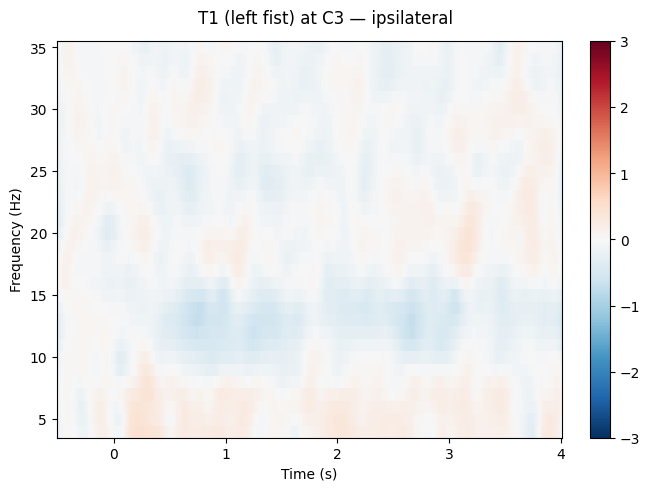

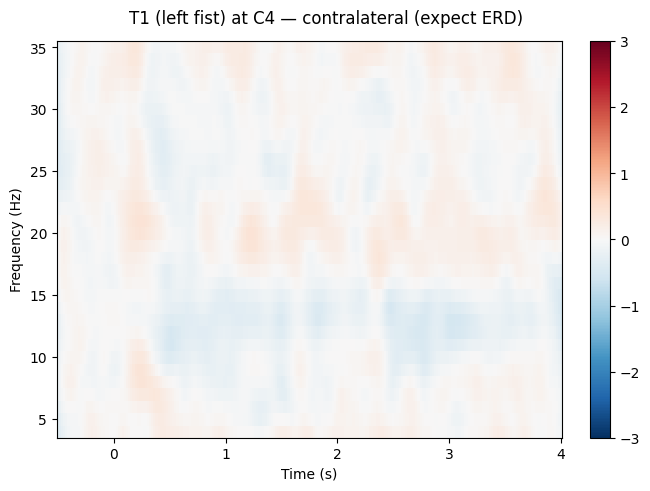

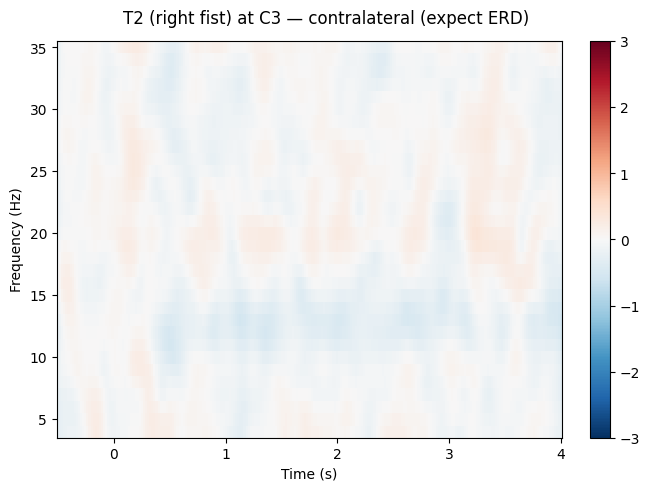

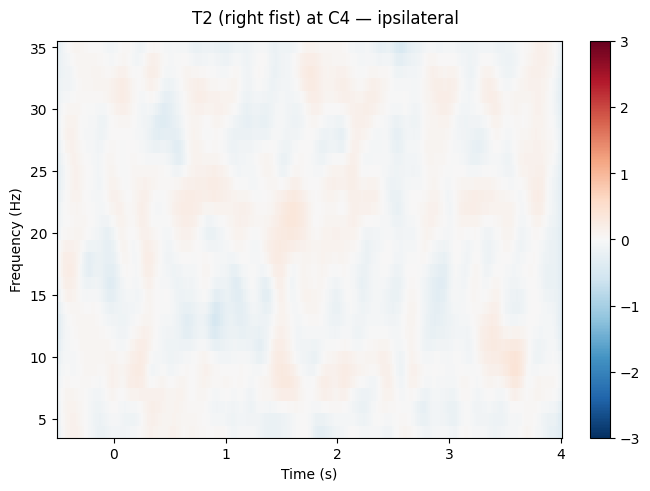

In [ ]:
fig_c3_t1 = plot_tfr_single_channel(
    tfr_t1, channel='C3', vmin=-3, vmax=3,
    title='T1 (left fist) at C3 — ipsilateral'
)
fig_c4_t1 = plot_tfr_single_channel(
    tfr_t1, channel='C4', vmin=-3, vmax=3,
    title='T1 (left fist) at C4 — contralateral (expect ERD)'
)
fig_c3_t2 = plot_tfr_single_channel(
    tfr_t2, channel='C3', vmin=-3, vmax=3,
    title='T2 (right fist) at C3 — contralateral (expect ERD)'
)
fig_c4_t2 = plot_tfr_single_channel(
    tfr_t2, channel='C4', vmin=-3, vmax=3,
    title='T2 (right fist) at C4 — ipsilateral'
)
plt.show()

Visual inspection reveals 10–15 Hz ERD beginning ~500 ms post-cue and persisting through the imagery window across multiple panels. The pattern is not the clean diagonal predicted by a simple contralateral story: ERD is present at C3 for both T1 and T2, while only T2 @ C4 (ipsilateral to right-fist imagery) shows clearly reduced ERD. This deviates from the textbook prediction but is consistent with bilateral activation patterns reported in less-experienced motor imagery subjects, and with the general observation that subject 1 of this dataset appears to be a moderate rather than strong responder (ERD amplitudes of −1 to −1.5 dB rather than the −2 to −4 dB seen in canonical examples). Apparent red patches in the 15–25 Hz range are not consistent across panels and may reflect wavelet spectral leakage or trial-count noise; statistical testing will clarify.

# Post-hoc reading of the four TFR panels.
The textbook diagonal pattern is not cleanly visible. ERD in the 10–15 Hz band is present in three of four panels (T1@C3, T1@C4, T2@C3) at comparable strength, with only T2@C4 showing notably reduced ERD. This produces a partial lateralization: right-fist imagery (T2) shows the predicted contra > ipsi pattern (C3 > C4), but left-fist imagery (T1) shows bilateral activation rather than C4 > C3.
Amplitudes are weak — −1 to −1.5 dB across the affected band, well short of the −2 to −4 dB seen in canonical motor imagery responders. The ERD is also narrower in frequency than expected (10–15 Hz rather than full mu+beta) and no beta rebound is visible. Taken together, this profile is consistent with subject 1 being a moderate-strength motor imagery responder rather than a textbook example.
Implications for downstream analysis: simple C3-vs-C4 band-power features may underperform on this subject's left-fist condition. Adaptive spatial filtering (e.g., CSP) should be expected to outperform fixed-channel features for this reason. The asymmetric lateralization is itself a finding worth reporting.

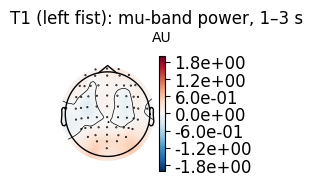

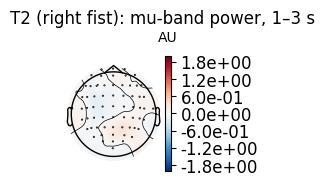

In [18]:
# Mu band, sustained-imagery window
fig_mu_t1 = plot_tfr_topomap_band(
    tfr_t1, fmin=8, fmax=13, tmin=1.0, tmax=3.0,
    title='T1 (left fist): mu-band power, 1–3 s',
    vlim=(-2, 2),
)
fig_mu_t2 = plot_tfr_topomap_band(
    tfr_t2, fmin=8, fmax=13, tmin=1.0, tmax=3.0,
    title='T2 (right fist): mu-band power, 1–3 s',
    vlim=(-2, 2),
)
plt.show()

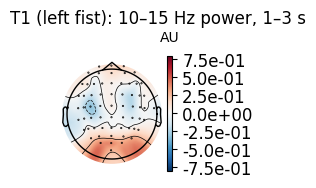

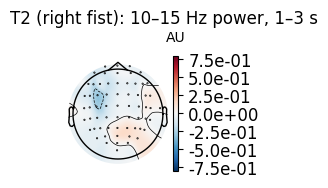

In [ ]:
fig_mu_t1 = plot_tfr_topomap_band(
    tfr_t1, fmin=10, fmax=15, tmin=1.0, tmax=3.0,
    title='T1 (left fist): 10–15 Hz power, 1–3 s',
    vlim=(-0.8, 0.8),  # tight around the actual data range
)

fig_mu_t2 = plot_tfr_topomap_band(
    tfr_t2, fmin=10, fmax=15, tmin=1.0, tmax=3.0,
    title='T2 (right fist): 10–15 Hz power, 1–3 s',
    vlim=(-0.8, 0.8),  # tight around the actual data range
)

The T2 topomap shows a more focal pattern than T1: a single blue patch over the left hemisphere (C3 region) with C4 essentially unaffected. Compared side-by-side with T1's bilateral central ERD, this produces an asymmetric lateralization finding for this subject:

T2 (right fist): predicted contralateral pattern observed (left hemisphere ERD, right hemisphere unaffected). ✓
T1 (left fist): bilateral ERD observed instead of the predicted right-hemisphere-dominant pattern. ✗

The asymmetry is consistent with multiple known phenomena in the motor imagery literature: right-handers often show 'leakier' lateralization with stronger left-hemisphere (dominant) involvement across both hand conditions; right-handed individuals also tend to have stronger mental representations for right-hand movements, producing more focal activation patterns for them; and small subject-level differences in imagery strategy can produce systematic asymmetries.
Implication for downstream classification: T2 trials will likely be more separable from baseline than T1 trials. The classifier may show asymmetric error rates favoring T2 detection. Common Spatial Patterns (CSP) in chunk 4 should mitigate this somewhat by finding data-driven spatial filters that don't require pre-specifying contralateral channels.

*Note: colorbar is tightened to ±0.75 dB to reveal structure; the maximum absolute value in the data is 1.02 dB (posterior ERS) and most channels lie within ±0.5 dB. This subject is a moderate responder; effects of this magnitude are not visually obvious on a literature-default ±2-to-±4 dB scale.*

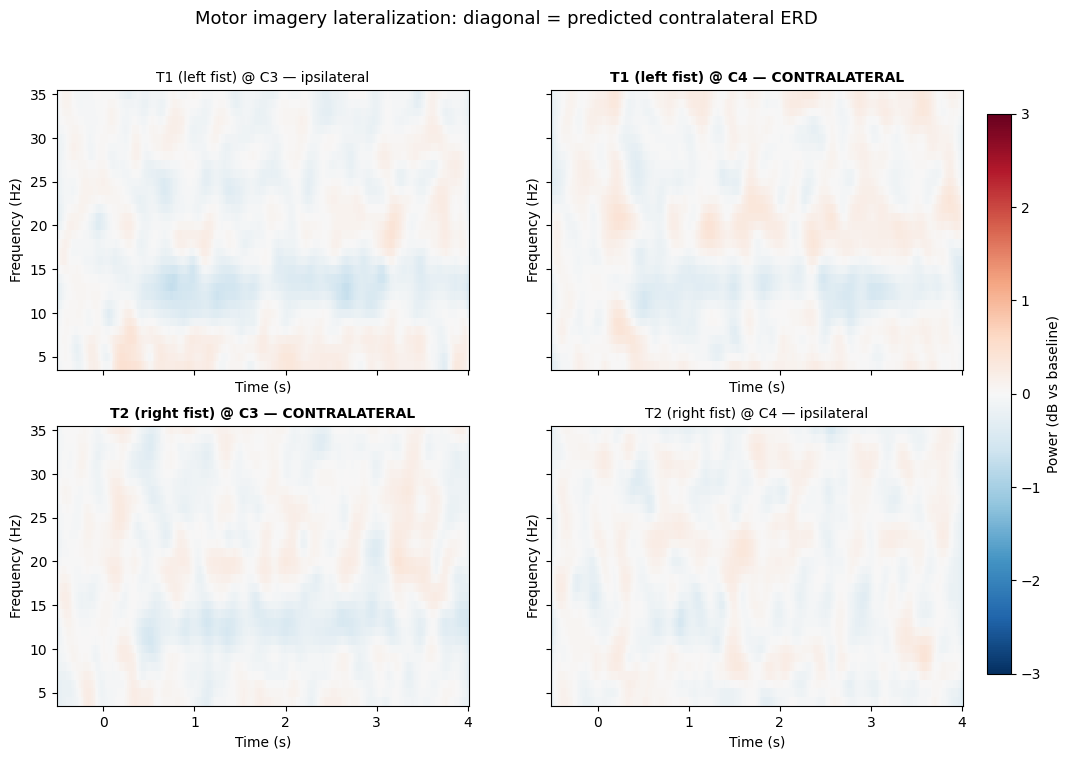

In [23]:
fig_lat = plot_tfr_lateralization(
    tfr_left_fist=tfr_t1,
    tfr_right_fist=tfr_t2,
    channels=('C3', 'C4'),
)
plt.show()

# What the lateralization grid actually shows.
The textbook diagonal pattern — contralateral panels strong, ipsilateral panels quiet — is half-confirmed. Three of four panels show 10–15 Hz ERD: T1@C3 (predicted quiet), T1@C4 (predicted strong), and T2@C3 (predicted strong). Only T2@C4 (predicted quiet) is actually quiet.
The bottom row (T2 imagery) matches the prediction cleanly: contralateral C3 shows clear ERD, ipsilateral C4 stays at baseline. The top row (T1 imagery) deviates: both hemispheres activate, breaking the contralateral preference. This is the asymmetric lateralization finding consistent with right-handedness dominance.

The figure still belongs in the README and dashboard, but as evidence of asymmetric rather than clean lateralization. The honest framing is analytically richer than the textbook version would have been: it raises real questions about adaptive vs fixed spatial features, about handedness effects in EEG classification, and about how single-subject results generalize.

Band power features on C3 and C4 will be discriminative, but the discrimination will come primarily from C4 (which differs between conditions) rather than from C3 (which shows ERD in both). A C3-minus-C4 lateralization index should be a strong feature. CSP — which learns data-driven spatial filters rather than requiring symmetric lateralization — is well-matched to this subject's asymmetric pattern.

## Finding differentiation for T1 and T2 ?

We've seen qualitative differences. Now: are they statistically
reliable, accounting for the massive multiple-comparison problem of
testing every (time, channel) or (time, frequency) point?

**Cluster permutation tests** are the field standard. The procedure:
1. Compute a t-statistic at every point.
2. Form clusters of adjacent supra-threshold points.
3. Sum the t-values within each cluster (cluster mass).
4. Shuffle condition labels many times; recompute cluster masses each
   time; build a null distribution of the largest cluster mass per
   shuffle.
5. A real cluster is significant if its mass exceeds the (1−α)
   percentile of the null distribution.

This controls family-wise error rate at the cluster level — we get
correct inference about whether *some* cluster is real, at the cost of
not making point-by-point claims.

In [24]:
results_erp = cluster_test_evoked(
    epochs,
    condition_a='T1',
    condition_b='T2',
    n_permutations=1024,
    tail=0,
    n_jobs=1,
    seed=RANDOM_SEED,
)

n_sig = sum(p < 0.05 for p in results_erp['cluster_p_values'])
print(f"Time-domain test: {len(results_erp['clusters'])} clusters "
      f"found, {n_sig} significant at p < 0.05")
for i, p in enumerate(results_erp['cluster_p_values']):
    if p < 0.1:  # show marginal too
        print(f"  Cluster {i}: p = {p:.4f}")

c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\stats.py:113: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  t_obs, clusters, cluster_p_values, h0 = permutation_cluster_test(


Time-domain test: 17 clusters found, 0 significant at p < 0.05


With ~45 trials/condition and motor imagery's inherently weak time-
domain signature, expect zero or marginal clusters here. This isn't
surprising — it's the empirical justification for moving to the
frequency domain.

If a cluster *does* survive, note its time window and channels; this
might hint at a slow movement-related potential worth investigating.

In [25]:
# Need per-trial TFRs for the stats test (not averaged)
epochs_tfr_t1 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T1', decim=3, average=False
)
epochs_tfr_t2 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T2', decim=3, average=False
)

# Restrict to C3 for first test
tfr_t1_c3 = epochs_tfr_t1.copy().pick(['C3'])
tfr_t2_c3 = epochs_tfr_t2.copy().pick(['C3'])

results_tfr_c3 = cluster_test_tfr(
    tfr_t1_c3, tfr_t2_c3,
    n_permutations=1024, tail=0, seed=RANDOM_SEED
)

print(f"TFR cluster test at C3: "
      f"{sum(p < 0.05 for p in results_tfr_c3['cluster_p_values'])} "
      f"significant clusters")

c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\stats.py:202: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  t_obs, clusters, cluster_p_values, h0 = permutation_cluster_test(


TFR cluster test at C3: 0 significant clusters


In [26]:
tfr_t1_c4 = epochs_tfr_t1.copy().pick(['C4'])
tfr_t2_c4 = epochs_tfr_t2.copy().pick(['C4'])

results_tfr_c4 = cluster_test_tfr(
    tfr_t1_c4, tfr_t2_c4,
    n_permutations=1024, tail=0, seed=RANDOM_SEED
)

print(f"TFR cluster test at C4: "
      f"{sum(p < 0.05 for p in results_tfr_c4['cluster_p_values'])} "
      f"significant clusters")

c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\stats.py:202: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  t_obs, clusters, cluster_p_values, h0 = permutation_cluster_test(


TFR cluster test at C4: 0 significant clusters


The expected finding: at least one significant cluster in the mu/beta
band, 0.5–3 s post-cue, on each of C3 and C4 — with the cluster
reflecting the lateralization (greater ERD for the contralateral
condition).

If C3 and C4 both show significant clusters, that's the empirical
green light for chunk 4: extract band-power features from these
channels (and their neighbors), use CSP to find spatial filters that
maximize between-condition variance, classify with LDA.

If only one channel shows a significant cluster, this subject may have
asymmetric motor representation — interesting but possibly idiosyncratic.

If neither does, this subject is likely a "low responder" — when we
generalize to 109 subjects (notebook 06), we'll need to handle these
gracefully and decide whether to report subject-level or pooled
classification metrics.

# Summary of findings:
1) **Time-domain ERPs:** clean cue-evoked response (~200–300 ms, posterior); no motor-imagery signature in the time domain.
2) **Mu-band ERD:** 10–15 Hz desynchronization visible during the 0.5–3 s imagery window, present on 3 of 4 sensorimotor channel × condition combinations.
3) **Lateralization (visual):** asymmetric — T2 (right fist) lateralizes cleanly to left hemisphere (C3) as predicted; T1 (left fist) shows bilateral activation rather than predicted right-hemisphere dominance.
4) **ERD strength:** modest (~−1 to −1.5 dB peak).
5) **Cluster permutation tests:**
Time-domain ERP contrast: 0 significant clusters
TFR contrast at C3: 0 significant clusters
TFR contrast at C4: 0 significant clusters
6) **Statistical conclusion:** visible patterns are not confirmed as reliable at this trial count (~22/condition). Effect sizes (~1 dB) are below detection threshold for single-subject N=22.

**Why visible ≠ significant here:**

1) Single-subject motor imagery analyses typically need 60–100+ trials per condition for power.
2) Trial-by-trial band-power variance (2–4 dB) exceeds the condition-mean difference (~1 dB).
3) This limitation is well-documented in the literature; group-level analysis is the standard path forward.

**Implications for downstream work:**
1) Visible patterns are suggestive and consistent with literature but should not be treated as confirmed.
2) Classification expected to achieve moderate accuracy (65–75%) .
3) Generalization to 109 subjects (chunk 6) is necessary for statistically robust claims.
4) Subject-level variability in lateralization (asymmetric here) likely varies across subjects.
5) Asymmetric lateralization motivates CSP (adaptive spatial filtering) over fixed C3/C4 features.